In [1]:
# V(St​)=V(St​)+α[Rt+1​+γV(St+1​)−V(St​)] for TD
# here instead we not wait for complete full episode to update ...
# here we LEARNNNNN during episode at each steppppppppppp

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output

In [3]:
GRID_SIZE = 5

start_state = (0,0)
goal_state = (4,4)

actions = ["up","down","left","right"]

In [4]:
def step(state, action):

    r, c = state

    if action == "up":
        r = max(r-1, 0)

    elif action == "down":
        r = min(r+1, GRID_SIZE-1)

    elif action == "left":
        c = max(c-1, 0)

    elif action == "right":
        c = min(c+1, GRID_SIZE-1)

    next_state = (r,c)

    reward = 1 if next_state == goal_state else -0.02

    return next_state, reward

In [5]:
states = [(r,c) for r in range(GRID_SIZE) for c in range(GRID_SIZE)]
states

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (4, 0),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 4)]

In [6]:
# TD(0) value initialization
V = {s:0 for s in states}

alpha = 0.1
gamma = 0.9
episodes = 2000

In [7]:
# TD learning...
for ep in range(episodes):

    state = start_state

    while state != goal_state:

        action = random.choice(actions)

        next_state, reward = step(state, action)

        # TD Update
        V[state] = V[state] + alpha * (reward + gamma * V[next_state] - V[state])

        state = next_state

In [8]:
# leeet initializee Q tableee
Q = {}

for s in states:
    Q[s] = {a:0 for a in actions}

In [9]:
# e - greedy policcyy
epsilon = 0.1

def choose_action(state):

    if random.random() < epsilon:
        return random.choice(actions)

    else:
        return max(Q[state], key=Q[state].get)

In [10]:
# SARSA Algoo
for ep in range(2000):

    state = start_state
    action = choose_action(state)

    while state != goal_state:

        next_state, reward = step(state, action)

        next_action = choose_action(next_state)

        Q[state][action] += alpha * (
            reward + gamma * Q[next_state][next_action] - Q[state][action]
        )

        state = next_state
        action = next_action

In [11]:
# Q learning algoo
for ep in range(2000):

    state = start_state

    while state != goal_state:

        action = choose_action(state)

        next_state, reward = step(state, action)

        best_next = max(Q[next_state].values())

        Q[state][action] += alpha * (
            reward + gamma * best_next - Q[state][action]
        )

        state = next_state

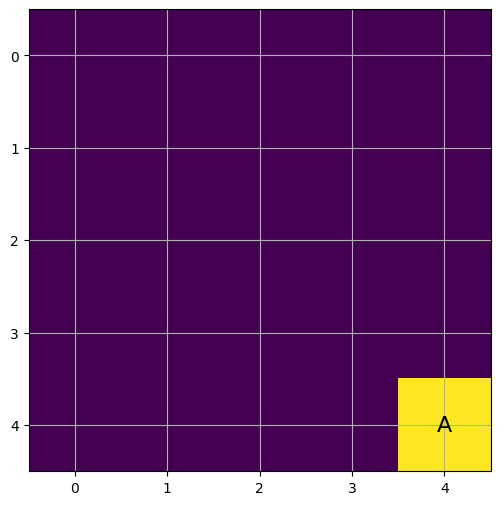

Goal Reached!
Path: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4)]


In [12]:
state = start_state
path = [state]

while state != goal_state:

    action = max(Q[state], key=Q[state].get)

    state,_ = step(state, action)

    path.append(state)

    grid = np.zeros((GRID_SIZE, GRID_SIZE))

    ar,ac = state
    gr,gc = goal_state

    grid[gr][gc] = 1
    grid[ar][ac] = 2

    clear_output(wait=True)

    plt.figure(figsize=(6,6))
    plt.imshow(grid)

    plt.xticks(range(GRID_SIZE))
    plt.yticks(range(GRID_SIZE))
    plt.grid()

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):

            if (r,c) == state:
                plt.text(c,r,"A",ha='center',va='center',fontsize=16)

            elif (r,c) == goal_state:
                plt.text(c,r,"G",ha='center',va='center',fontsize=16)

    plt.show()

    time.sleep(0.4)

print("Goal Reached!")
print("Path:", path)

In [13]:
print("\nFull Q-Learning Table:\n")

for state in Q:
    print(f"State {state}:")

    for action in Q[state]:
        print(f"   {action:6} : {Q[state][action]:.4f}")

    print("-"*30)


Full Q-Learning Table:

State (0, 0):
   up     : 0.3162
   down   : 0.3726
   left   : 0.3160
   right  : 0.3740
------------------------------
State (0, 1):
   up     : 0.3735
   down   : 0.4363
   left   : 0.3158
   right  : 0.4377
------------------------------
State (0, 2):
   up     : 0.4375
   down   : 0.5086
   left   : 0.3736
   right  : 0.5050
------------------------------
State (0, 3):
   up     : 0.1782
   down   : 0.5868
   left   : 0.0686
   right  : -0.0146
------------------------------
State (0, 4):
   up     : -0.0112
   down   : 0.0595
   left   : -0.0127
   right  : -0.0114
------------------------------
State (1, 0):
   up     : 0.0845
   down   : 0.0226
   left   : 0.0736
   right  : 0.4376
------------------------------
State (1, 1):
   up     : 0.1536
   down   : 0.3073
   left   : 0.1701
   right  : 0.5086
------------------------------
State (1, 2):
   up     : 0.4374
   down   : 0.5873
   left   : 0.4376
   right  : 0.5866
------------------------------
Sta

In [14]:
num_states = len(Q)
num_actions = len(actions)

print("Number of States:", num_states)
print("Number of Actions per State:", num_actions)
print("Total Q-values stored:", num_states * num_actions)

Number of States: 25
Number of Actions per State: 4
Total Q-values stored: 100
